## Universidad Panamericana Campus Aguascalientes
## Maestría en Inteligencia Artificial y Ciencia de Datos
### Introducción al Aprendizaje Automático
**Actividad 3.** Regresión Lineal Múltiple

ID: 0286155

Alumno: Manuel Alejandro Serrano Macias

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos
datos_tinto = pd.read_csv('winequality-red.csv', sep=';')
datos_blanco = pd.read_csv('winequality-white.csv', sep=';')

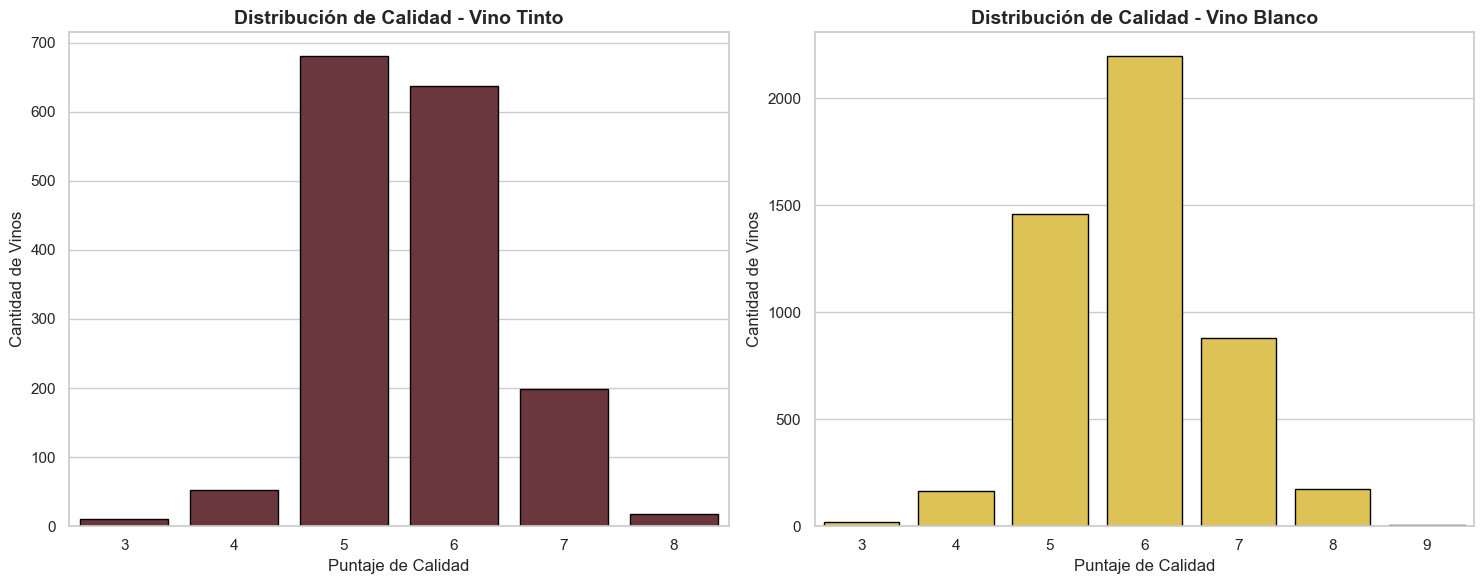

In [13]:
sns.set(style="whitegrid")

def graficar_distribucion_calidad(datos_tinto, datos_blanco):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico 1: Vino Tinto
    # Usamos countplot para contar cuántos vinos hay de cada nota
    sns.countplot(x='quality', data=datos_tinto, color="#722F37", 
                  edgecolor='black', ax=axes[0])
    axes[0].set_title('Distribución de Calidad - Vino Tinto', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Puntaje de Calidad', fontsize=12)
    axes[0].set_ylabel('Cantidad de Vinos', fontsize=12)
    
    # Gráfico 2: Vino Blanco
    sns.countplot(x='quality', data=datos_blanco, color="#F4D03F", 
                  edgecolor='black', ax=axes[1])
    axes[1].set_title('Distribución de Calidad - Vino Blanco', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Puntaje de Calidad', fontsize=12)
    axes[1].set_ylabel('Cantidad de Vinos', fontsize=12)
    plt.tight_layout()
    plt.savefig('distribucion_calidad.png', dpi=300)
    plt.show()

graficar_distribucion_calidad(datos_tinto, datos_blanco)

In [14]:
def reportar_metricas_regresion(datos, nombre_dataset):
    # Definición de X (variables independientes) y y (target)
    X = datos.drop('quality', axis=1)
    y = datos['quality']
    
    # Entrenamiento
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Predicciones
    y_pred = modelo.predict(X)
    
    # --- Cálculo de métricas---
    
    # 1. MSE (Error Cuadrático Medio)
    mse = mean_squared_error(y, y_pred)
    
    # 2. RMSE (Raíz del Error Cuadrático Medio)
    rmse = np.sqrt(mse)
    
    # 3. R² (Coeficiente de Determinación)
    r2 = r2_score(y, y_pred)
    
    # 4. R² Ajustado
    n = len(y)       # número de observaciones
    p = X.shape[1]   # número de predictores
    r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    # 5. Construcción de la Ecuación de Regresión
    terminos = []
    for col, coef in zip(X.columns, modelo.coef_):
        terminos.append(f"({coef:.4f} * {col})")
    
    ecuacion = f"Calidad = {modelo.intercept_:.4f} + " + " + ".join(terminos)
    
    # Resultados
    print(f"Resultados para: {nombre_dataset}")
    print("-" * 30)
    print(f"MSE (Mean Squared Error):         {mse:.4f}")
    print(f"RMSE (Root Mean Squared Error):   {rmse:.4f}")
    print(f"R² (Coeficiente Determinación):   {r2:.4f}")
    print(f"R² Ajustado:                      {r2_ajustado:.4f}")
    print("-" * 30)
    print("Ecuación del Modelo:")
    print(ecuacion)
    print("\n" + "="*80 + "\n")

reportar_metricas_regresion(datos_tinto, "Vino Tinto")
reportar_metricas_regresion(datos_blanco, "Vino Blanco")

Resultados para: Vino Tinto
------------------------------
MSE (Mean Squared Error):         0.4168
RMSE (Root Mean Squared Error):   0.6456
R² (Coeficiente Determinación):   0.3606
R² Ajustado:                      0.3561
------------------------------
Ecuación del Modelo:
Calidad = 21.9652 + (0.0250 * fixed acidity) + (-1.0836 * volatile acidity) + (-0.1826 * citric acid) + (0.0163 * residual sugar) + (-1.8742 * chlorides) + (0.0044 * free sulfur dioxide) + (-0.0033 * total sulfur dioxide) + (-17.8812 * density) + (-0.4137 * pH) + (0.9163 * sulphates) + (0.2762 * alcohol)


Resultados para: Vino Blanco
------------------------------
MSE (Mean Squared Error):         0.5632
RMSE (Root Mean Squared Error):   0.7504
R² (Coeficiente Determinación):   0.2819
R² Ajustado:                      0.2803
------------------------------
Ecuación del Modelo:
Calidad = 150.1928 + (0.0655 * fixed acidity) + (-1.8632 * volatile acidity) + (0.0221 * citric acid) + (0.0815 * residual sugar) + (-0.2473 

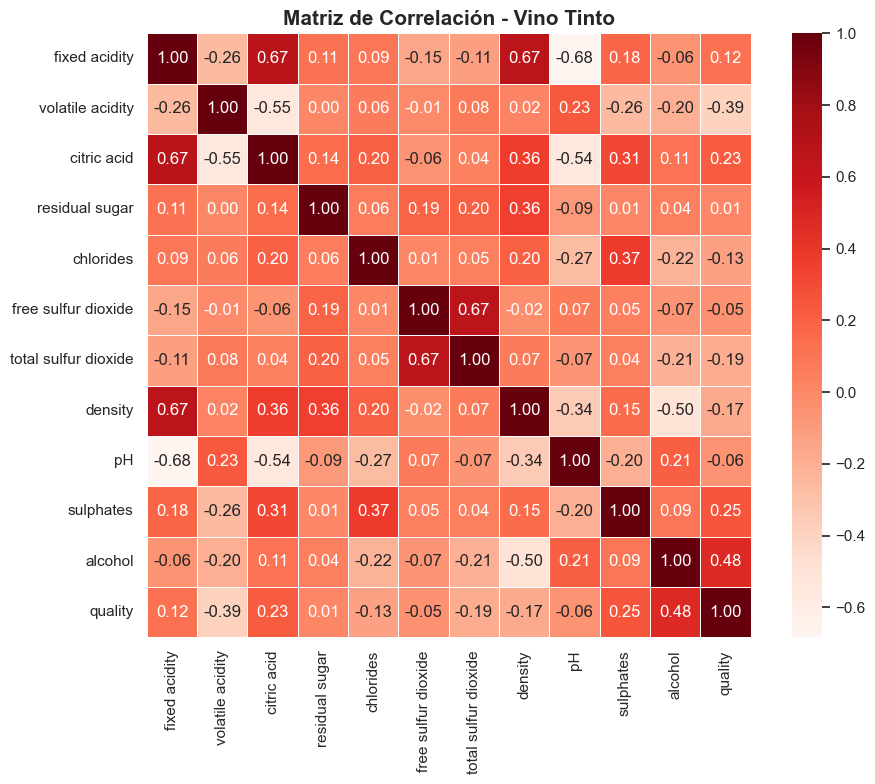

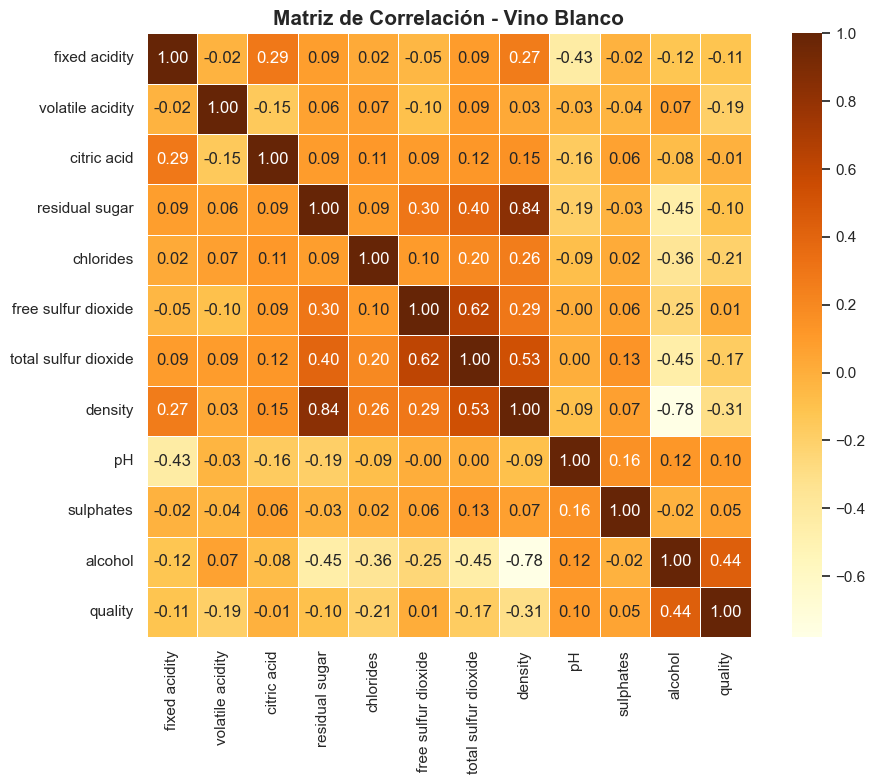

In [15]:
sns.set(style="white")

def graficar_correlacion(data, titulo, filename, color_map):
    plt.figure(figsize=(10, 8))
    
    # Calcular matriz de correlación
    corr = data.corr()
 
    # Generar Heatmap
    # annot=True muestra los números en los cuadros
    # fmt=".2f" limita a 2 decimales
    sns.heatmap(corr, annot=True, fmt=".2f", cmap=color_map, 
                cbar=True, square=True, linewidths=.5)
    plt.title(titulo, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

graficar_correlacion(datos_tinto, "Matriz de Correlación - Vino Tinto", "heatmap_tinto.png", "Reds")
graficar_correlacion(datos_blanco, "Matriz de Correlación - Vino Blanco", "heatmap_blanco.png", "YlOrBr")

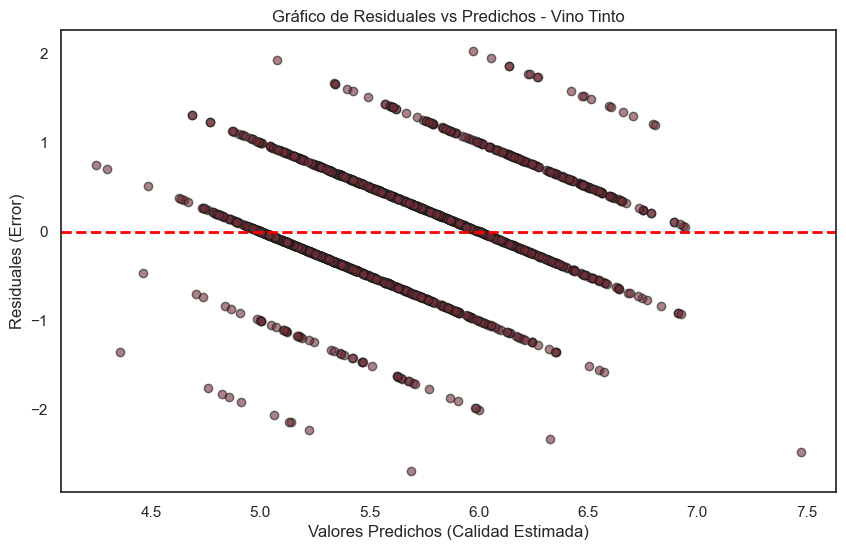

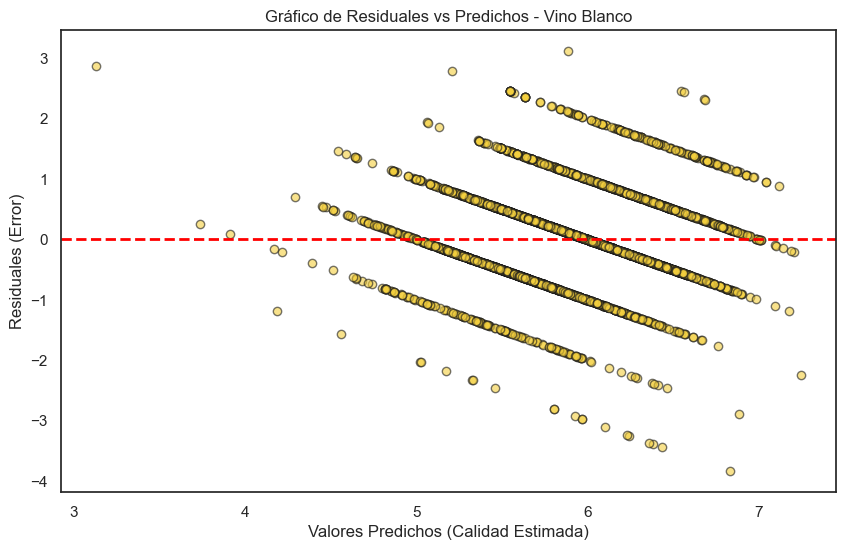

In [17]:
def evaluar_linealidad(datos, nombre_set):
    if "Tinto" in nombre_set:
        color_grafico = "#722F37"
        nombre_archivo = "linealidad_tinto"
    else:
        color_grafico = "#F4D03F"
        nombre_archivo = "linealidad_blanco"
        
    # Preparación de datos
    X = datos.drop('quality', axis=1)
    y = datos['quality']
    
    # Ajuste del modelo
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Cálculos de residuales
    y_pred = modelo.predict(X)
    residuales = y - y_pred
    
    # Graficación
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuales, alpha=0.6, edgecolors='k', color=color_grafico)
    
    # Línea de referencia en cero
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.title(f'Gráfico de Residuales vs Predichos - {nombre_set}')
    plt.xlabel('Valores Predichos (Calidad Estimada)')
    plt.ylabel('Residuales (Error)')
    plt.savefig(nombre_archivo, dpi=300) # dpi=300 es alta resolución para imprimir
    plt.show()

evaluar_linealidad(datos_tinto, "Vino Tinto")
evaluar_linealidad(datos_blanco, "Vino Blanco")

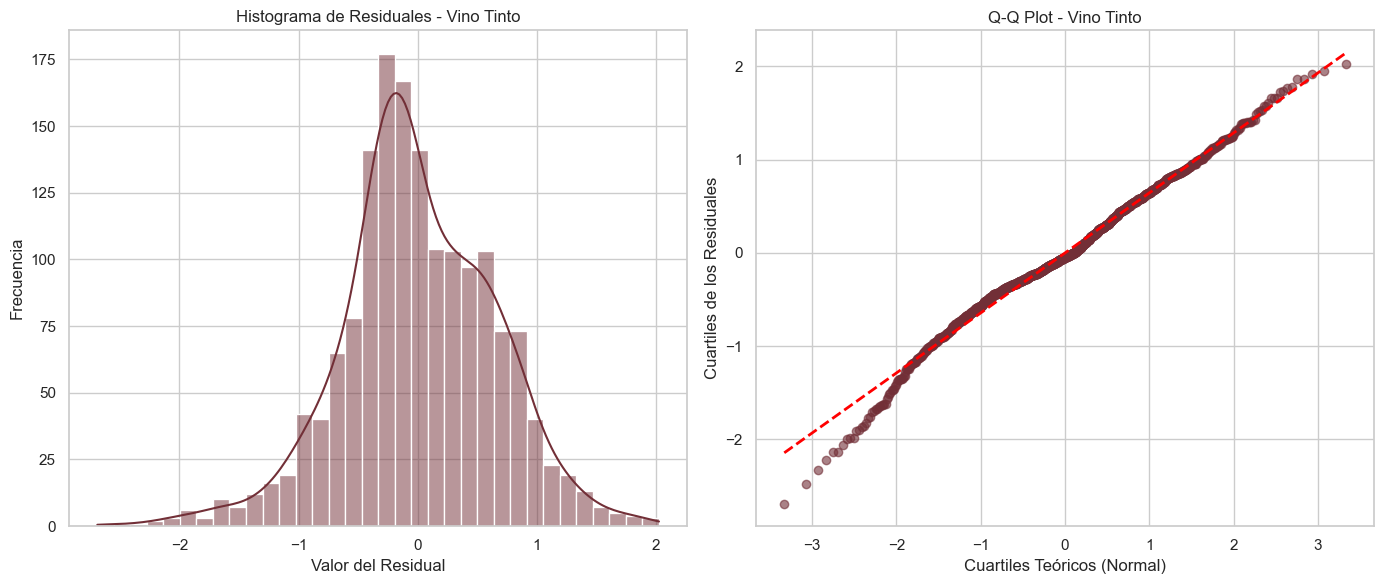

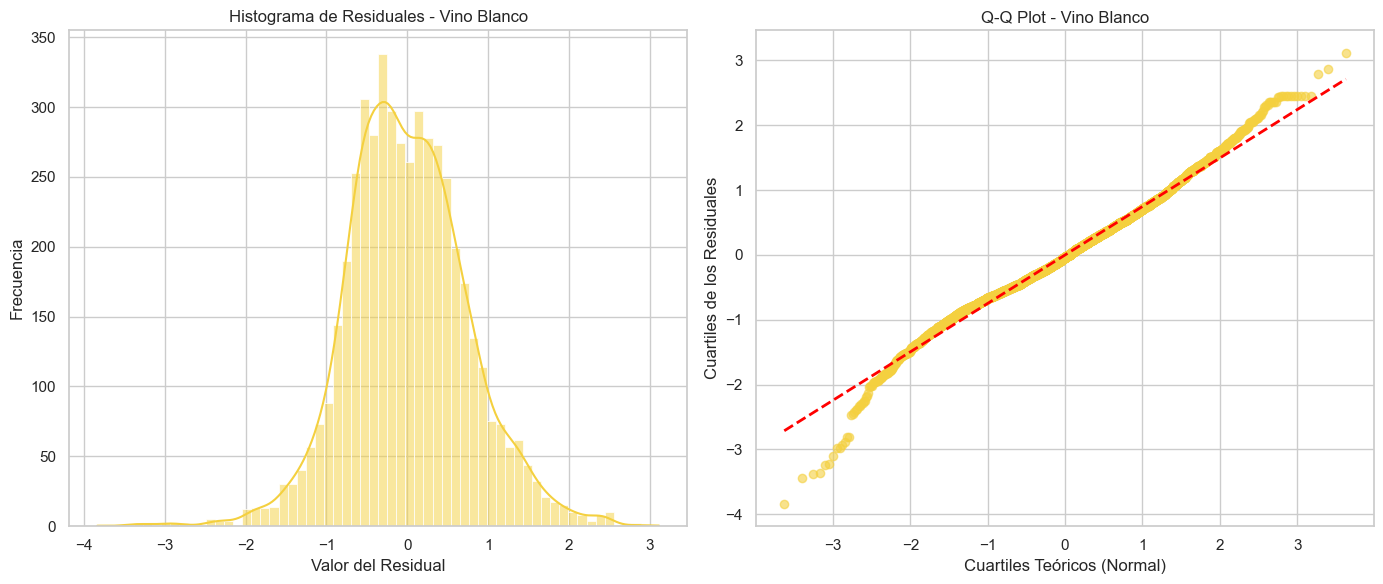

In [18]:
import scipy.stats as stats
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")

def evaluar_normalidad(datos, nombre_set):
    if "Tinto" in nombre_set:
        color_grafico = "#722F37"
        nombre_archivo = "normalidad_tinto"

    else:
        color_grafico = "#F4D03F"
        nombre_archivo = "normalidad_blanco"

    # Preparación y Ajuste
    X = datos.drop('quality', axis=1)
    y = datos['quality']
    
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Cálculo de Residuales
    y_pred = modelo.predict(X)
    residuales = y - y_pred
    
    # Graficación
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Gráfico A: Histograma con curva de densidad (KDE)
    sns.histplot(residuales, kde=True, color=color_grafico, ax=axes[0], edgecolor="white")
    axes[0].set_title(f'Histograma de Residuales - {nombre_set}')
    axes[0].set_xlabel('Valor del Residual')
    axes[0].set_ylabel('Frecuencia')
    
    # Gráfico B: Q-Q Plot
    # stats.probplot genera los puntos teóricos vs reales
    (osm, osr), (slope, intercept, r) = stats.probplot(residuales, dist="norm", plot=None)    
    axes[1].scatter(osm, osr, color=color_grafico, alpha=0.6)
    axes[1].plot(osm, slope*osm + intercept, color='red', linestyle='--', linewidth=2)
    axes[1].set_title(f'Q-Q Plot - {nombre_set}')
    axes[1].set_xlabel('Cuartiles Teóricos (Normal)')
    axes[1].set_ylabel('Cuartiles de los Residuales')
    plt.savefig(nombre_archivo, dpi=300)
    plt.tight_layout()
    plt.show()

# Ejecución de la prueba
evaluar_normalidad(datos_tinto, "Vino Tinto")
evaluar_normalidad(datos_blanco, "Vino Blanco")

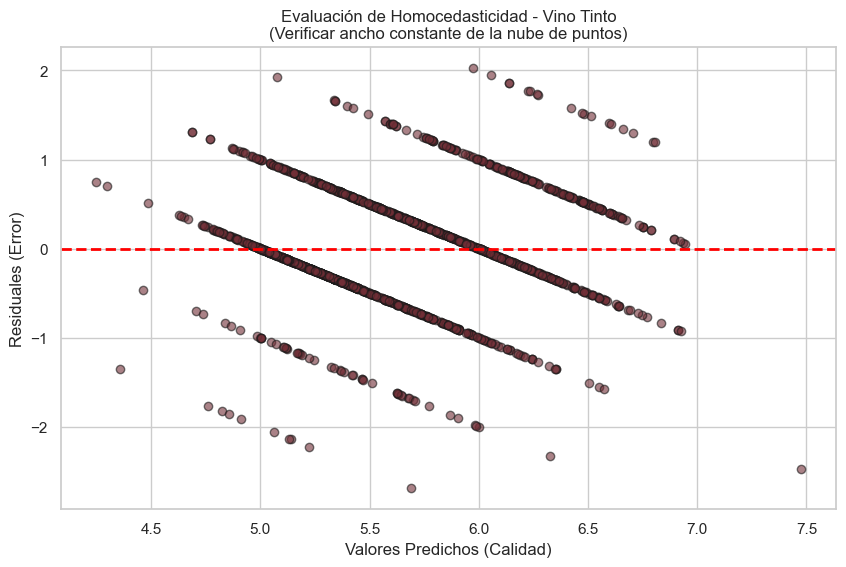

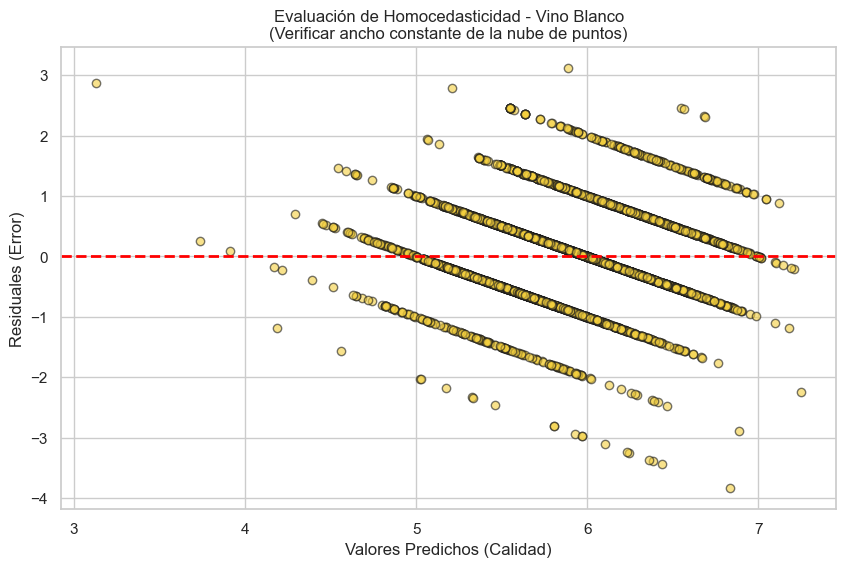

In [25]:
sns.set(style="whitegrid")

def evaluar_homocedasticidad(datos, nombre_set):

    # 1. Lógica interna de colores
    if "Tinto" in nombre_set:
        color_grafico = "#722F37" # Tinto
        nombre_archivo = "homocedasticidad_tinto"
    else:
        color_grafico = "#F4D03F" # Blanco
        nombre_archivo = "homocedasticidad_blanco"

    # 2. Preparación y Ajuste
    X = datos.drop('quality', axis=1)
    y = datos['quality']
    
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # 3. Cálculo de datos para el gráfico
    y_pred = modelo.predict(X)
    residuales = y - y_pred
    
    # 4. Graficación
    plt.figure(figsize=(10, 6))
    
    plt.scatter(y_pred, residuales, alpha=0.6, edgecolors='k', color=color_grafico)
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    
    plt.title(f'Evaluación de Homocedasticidad - {nombre_set}\n(Verificar ancho constante de la nube de puntos)')
    plt.xlabel('Valores Predichos (Calidad)')
    plt.ylabel('Residuales (Error)')
    plt.savefig(nombre_archivo, dpi=300)
    
    plt.show()

# Ejecución de la prueba
evaluar_homocedasticidad(datos_tinto, "Vino Tinto")
evaluar_homocedasticidad(datos_blanco, "Vino Blanco")

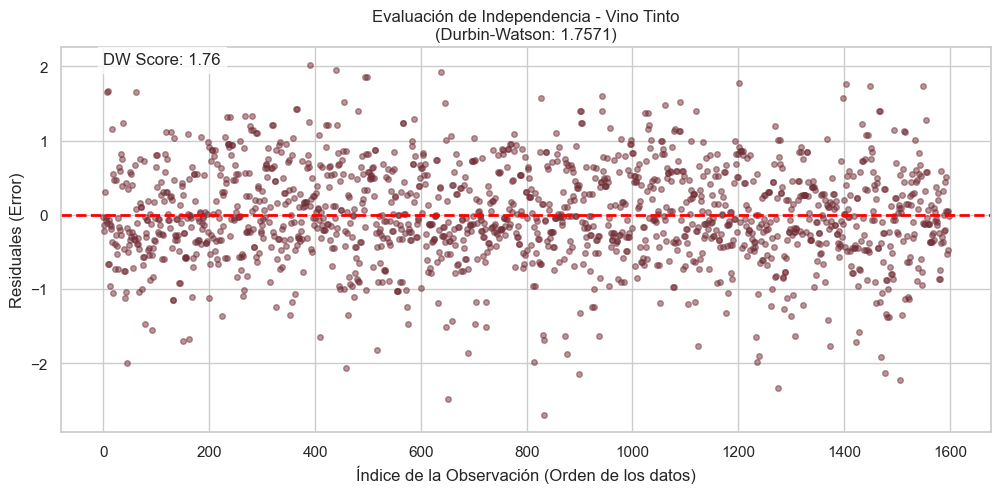

--- Diagnóstico de Independencia: Vino Tinto ---
Estadístico Durbin-Watson: 1.7571
>> Estatus: PASA (No hay correlación serial severa).




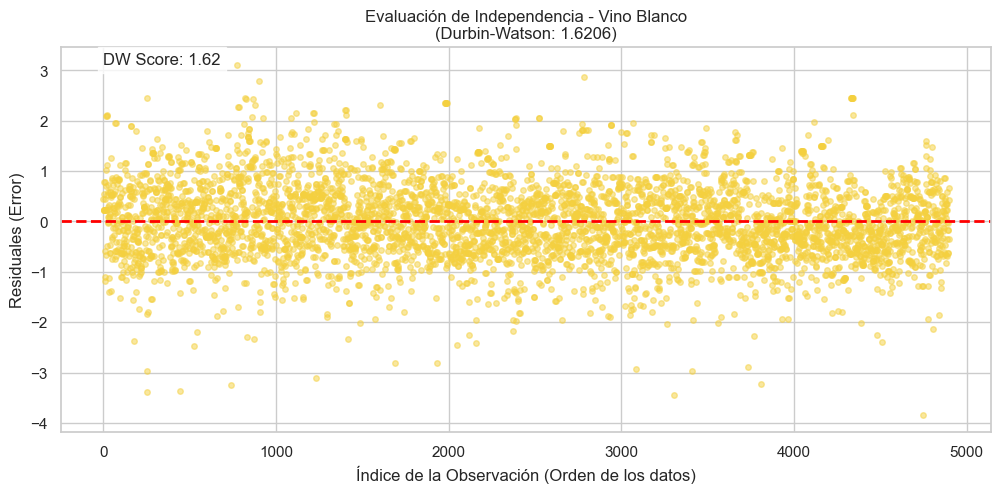

--- Diagnóstico de Independencia: Vino Blanco ---
Estadístico Durbin-Watson: 1.6206
>> Estatus: PASA (No hay correlación serial severa).




In [20]:
from statsmodels.stats.stattools import durbin_watson

def evaluar_independencia(datos, nombre_set):
    if "Tinto" in nombre_set:
        color_grafico = "#722F37"
        nombre_archivo = "independencia_tinto"
    else:
        color_grafico = "#F4D03F"
        nombre_archivo = "independencia_blanco"

    # Preparación y Ajuste
    X = datos.drop('quality', axis=1)
    y = datos['quality']
    
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Cálculo de Residuales
    y_pred = modelo.predict(X)
    residuales = y - y_pred
    
    # Cálculo del Estadístico Durbin-Watson
    # Nota: statmodels espera un array unidimensional
    dw_score = durbin_watson(residuales)
    
    # Graficación
    plt.figure(figsize=(12, 5))
    
    # Graficamos los residuales en orden secuencial (índice del dataframe)
    plt.plot(residuales.values, marker='o', linestyle='', alpha=0.5, 
             markersize=4, color=color_grafico)
    
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    
    plt.title(f'Evaluación de Independencia - {nombre_set}\n(Durbin-Watson: {dw_score:.4f})')
    plt.xlabel('Índice de la Observación (Orden de los datos)')
    plt.ylabel('Residuales (Error)')
    
    # Añadimos una etiqueta visual para el resultado numérico
    plt.text(0, residuales.max(), f'DW Score: {dw_score:.2f}', 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    plt.savefig(nombre_archivo, dpi=300)
    plt.show()
    
    print(f"--- Diagnóstico de Independencia: {nombre_set} ---")
    print(f"Estadístico Durbin-Watson: {dw_score:.4f}")
    if 1.5 < dw_score < 2.5:
        print(">> Estatus: PASA (No hay correlación serial severa).")
    else:
        print(">> Estatus: ALERTA (Posible autocorrelación).")
    print("\n")

evaluar_independencia(datos_tinto, "Vino Tinto")
evaluar_independencia(datos_blanco, "Vino Blanco")

In [21]:
from sklearn.feature_selection import RFE

def seleccion_variables_rfe(datos, nombre_set, n_variables=7):
    # Selecciona las variables más relevantes utilizando RFE (Recursive Feature Elimination).
    # Criterio: Elimina recursivamente las variables con menor peso (coeficiente) en el modelo.

    X = datos.drop('quality', axis=1)
    y = datos['quality']
    
    # Configuración del selector RFE
    # Usamos Regresión Lineal como estimador base
    estimador = LinearRegression()
    
    # Instanciamos RFE indicando cuántas variables queremos conservar
    selector = RFE(estimator=estimador, n_features_to_select=n_variables, step=1)
    
    # Ejecución de la selección
    selector.fit(X, y)
    
    # Identificación de variables seleccionadas
    variables_seleccionadas = X.columns[selector.support_]
    variables_eliminadas = X.columns[~selector.support_]

    print(f"--- Selección de Variables (RFE) para {nombre_set} ---")
    print(f"Variables Originales: {X.shape[1]}")
    print(f"Variables Seleccionadas ({n_variables}):")
    print(list(variables_seleccionadas))
    print(f"Variables Descartadas:")
    print(list(variables_eliminadas))
    print("\n")
    
    return list(variables_seleccionadas)

vars_tinto = seleccion_variables_rfe(datos_tinto, "Vino Tinto", n_variables=7)
vars_blanco = seleccion_variables_rfe(datos_blanco, "Vino Blanco", n_variables=7)

--- Selección de Variables (RFE) para Vino Tinto ---
Variables Originales: 11
Variables Seleccionadas (7):
['volatile acidity', 'citric acid', 'chlorides', 'density', 'pH', 'sulphates', 'alcohol']
Variables Descartadas:
['fixed acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide']


--- Selección de Variables (RFE) para Vino Blanco ---
Variables Originales: 11
Variables Seleccionadas (7):
['volatile acidity', 'residual sugar', 'chlorides', 'density', 'pH', 'sulphates', 'alcohol']
Variables Descartadas:
['fixed acidity', 'citric acid', 'free sulfur dioxide', 'total sulfur dioxide']




In [23]:
from sklearn.model_selection import cross_val_score, KFold

def validar_modelo_cv(datos, variables_seleccionadas, nombre_set, k=10):
    # Realiza validación cruzada (K-Fold) para evaluar el desempeño robusto del modelo.
    # Reporta MSE, RMSE y R² promedio de los folds.
    
    # Filtramos el dataset para usar SOLO las variables seleccionadas por RFE
    X = datos[variables_seleccionadas]
    y = datos['quality']
    
    # Configuración del modelo y del esquema de validación
    modelo = LinearRegression()

    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    
    # Ejecución de la Validación Cruzada
    # Scikit-learn usa 'neg_mean_squared_error' porque su convención es "maximizar score".
    # Por eso ponemos un signo negativo al principio para volverlo positivo (MSE real).
    scores_mse = -cross_val_score(modelo, X, y, cv=kf, scoring='neg_mean_squared_error')
    
    # Para R2, el score es directo
    scores_r2 = cross_val_score(modelo, X, y, cv=kf, scoring='r2')
    
    # Cálculo de promedios y desviación estándar (para ver estabilidad)
    mse_promedio = scores_mse.mean()
    rmse_promedio = np.sqrt(mse_promedio)
    r2_promedio = scores_r2.mean()

    print(f"--- Reporte de Validación Cruzada (k={k}): {nombre_set} ---")
    print(f"Variables utilizadas: {len(variables_seleccionadas)}")
    print(f"MSE Promedio:         {mse_promedio:.4f} (std: +/- {scores_mse.std():.4f})")
    print(f"RMSE Promedio:        {rmse_promedio:.4f}")
    print(f"R² Promedio:          {r2_promedio:.4f}")
    print("-" * 50 + "\n")

validar_modelo_cv(datos_tinto, vars_tinto, "Vino Tinto")
validar_modelo_cv(datos_blanco, vars_blanco, "Vino Blanco")

--- Reporte de Validación Cruzada (k=10): Vino Tinto ---
Variables utilizadas: 7
MSE Promedio:         0.4300 (std: +/- 0.0574)
RMSE Promedio:        0.6558
R² Promedio:          0.3377
--------------------------------------------------

--- Reporte de Validación Cruzada (k=10): Vino Blanco ---
Variables utilizadas: 7
MSE Promedio:         0.5693 (std: +/- 0.0367)
RMSE Promedio:        0.7545
R² Promedio:          0.2725
--------------------------------------------------

